# Brazilian Port Lead Time — EDA and Leakage-Aware Baseline Modeling

This notebook is a practical first pass through the public Brazilian port-call dataset. It introduces the prediction problem, inspects the model-ready data, performs concise exploratory analysis, and trains two simple baselines while respecting the official temporal split.

A vessel's **port stay** is the elapsed time between arrival at a port and departure from that port. It is one component of maritime and supply-chain lead time, and it can be highly variable across ports, vessel histories, operation types, weather conditions, and operational congestion.

In this dataset, the prediction setting is:

- Unit of observation: one consolidated vessel port call.
- Identifier: `port_call_id`.
- Prediction timestamp: `arrival_port_ts`.
- Target: `t_total_port_stay_h`, the total vessel stay in port, measured in hours.

The goal here is educational baseline modeling, not a full reproduction of the MBA thesis workflow. Later experiments can build on the same leakage-aware protocol.

Links:

- Kaggle dataset: https://www.kaggle.com/datasets/tiagoalberione/brazilian-port-lead-time-2023-2025
- GitHub repository: https://github.com/tiagoalberione/port-leadtime-prediction

## 1. Imports and Configuration

Only mainstream Kaggle packages are used: pandas, NumPy, matplotlib, and scikit-learn. The random state is fixed for reproducibility.

In [1]:
from pathlib import Path
import time


import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, median_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder


RANDOM_STATE = 42
TARGET = "t_total_port_stay_h"
DATE_COL = "arrival_port_ts"
ID_COL = "port_call_id"
SPLIT_COL = "split"
BASE_COLUMNS = [ID_COL, DATE_COL, TARGET, SPLIT_COL]
MODEL_FILE = "brazilian_port_calls_model_ready_2023_2025.csv"
SPLIT_ORDER = ["train", "validation", "calibration", "final_test"]
DEVELOPMENT_SPLITS = ["train", "validation", "calibration"]

NOTEBOOK_START = time.perf_counter()

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)
plt.rcParams.update(
    {
        "figure.figsize": (9, 5),
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    }
)

## 2. Load Data

The notebook reads the single public CSV file. On Kaggle, attach the dataset and the helper will search under `/kaggle/input`. For local development, it searches the repository-generated `kaggle/dataset/output/` folder.

In [2]:
def find_input_file(filename, local_relative_dirs):
    candidates = []

    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        candidates.extend(sorted(kaggle_input.rglob(filename)))

    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        for relative_dir in local_relative_dirs:
            candidates.append(base / relative_dir / filename)

    for candidate in candidates:
        if candidate.exists():
            return candidate

    searched = "\n".join(str(path) for path in candidates[:20])
    raise FileNotFoundError(f"Could not find {filename}. First searched locations:\n{searched}")


def display_path(path):
    path = Path(path).resolve()
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        try:
            return str(path.relative_to(base))
        except ValueError:
            pass
    return str(path)


model_path = find_input_file(MODEL_FILE, [Path("kaggle/dataset/output"), Path(".")])

df = pd.read_csv(model_path, parse_dates=[DATE_COL])

print(f"Loaded model-ready data from: {display_path(model_path)}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print(f"Date range: {df[DATE_COL].min()} to {df[DATE_COL].max()}")
print(f"Target: {TARGET}")
print("\nSplit counts:")
print(df[SPLIT_COL].value_counts().reindex(SPLIT_ORDER).to_string())
print(f"Unique ports: {df['port'].nunique(dropna=True):,}")

required_columns = set(BASE_COLUMNS)
missing_required = sorted(required_columns - set(df.columns))
assert not missing_required, f"Missing required columns: {missing_required}"
assert df[ID_COL].is_unique, "port_call_id should be unique in the model-ready dataset."
assert df[TARGET].notna().all(), "The target should be complete."
assert (df[TARGET] >= 0).all(), "The target should be non-negative."
assert set(df[SPLIT_COL].dropna()) == set(SPLIT_ORDER), "Unexpected split labels."
assert df[SPLIT_COL].notna().all(), "All rows should have an official split."

split_bounds = {
    "train": ("2023-01-01", "2024-07-01"),
    "validation": ("2024-07-01", "2025-01-01"),
    "calibration": ("2025-01-01", "2025-07-01"),
    "final_test": ("2025-07-01", "2026-01-01"),
}
for split_name, (start, end) in split_bounds.items():
    part = df[df[SPLIT_COL] == split_name]
    assert ((part[DATE_COL] >= start) & (part[DATE_COL] < end)).all(), f"{split_name} has dates outside bounds."

Loaded model-ready data from: kaggle\dataset\output\brazilian_port_calls_model_ready_2023_2025.csv
Shape: 129,625 rows x 124 columns
Date range: 2023-01-01 00:08:00 to 2025-12-31 23:00:00
Target: t_total_port_stay_h

Split counts:
split
train          66909
validation     20362
calibration    21352
final_test     21002
Unique ports: 109


## 3. Dataset Overview

Each row is one consolidated vessel port call. The model-ready file contains predictors designed for arrival-time modeling. Historical variables are already precomputed with walk-forward temporal semantics, so they are safer for modeling than ad hoc aggregates built after seeing the full timeline.

To keep the final holdout clean, the exploratory sections below use the development period: `train`, `validation`, and `calibration`. The `final_test` period is kept for the locked evaluation only.

In [3]:
predictors = [column for column in df.columns if column not in BASE_COLUMNS]
development_df = df[df[SPLIT_COL].isin(DEVELOPMENT_SPLITS)].copy()

overview = pd.DataFrame(
    [
        ("Rows", f"{len(df):,}"),
        ("Rows in development period", f"{len(development_df):,}"),
        ("Predictors", f"{len(predictors):,}"),
        ("Start date", df[DATE_COL].min()),
        ("End date", df[DATE_COL].max()),
        ("Ports", f"{df['port'].nunique(dropna=True):,}"),
        ("Missing target", f"{df[TARGET].isna().sum():,}"),
    ],
    columns=["Item", "Value"],
)
display(overview)

,Item,Value
0,Rows,"129,625"
1,Rows in development period,"108,623"
2,Predictors,120
3,Start date,2023-01-01 00:08:00
4,End date,2025-12-31 23:00:00
5,Ports,109
6,Missing target,0


## 4. Target Exploration

The target is right-skewed: many calls finish in a moderate time, while a smaller number remain in port for much longer. The long tail is part of the real prediction problem, so it is not removed for modeling. The second plot clips only the x-axis for visualization.

,t_total_port_stay_h
count,"108,623.00"
mean,71.24
median,38.17
std,98.19
p75,80.78
p90,163.83
p95,255.60
max,"1,280.08"


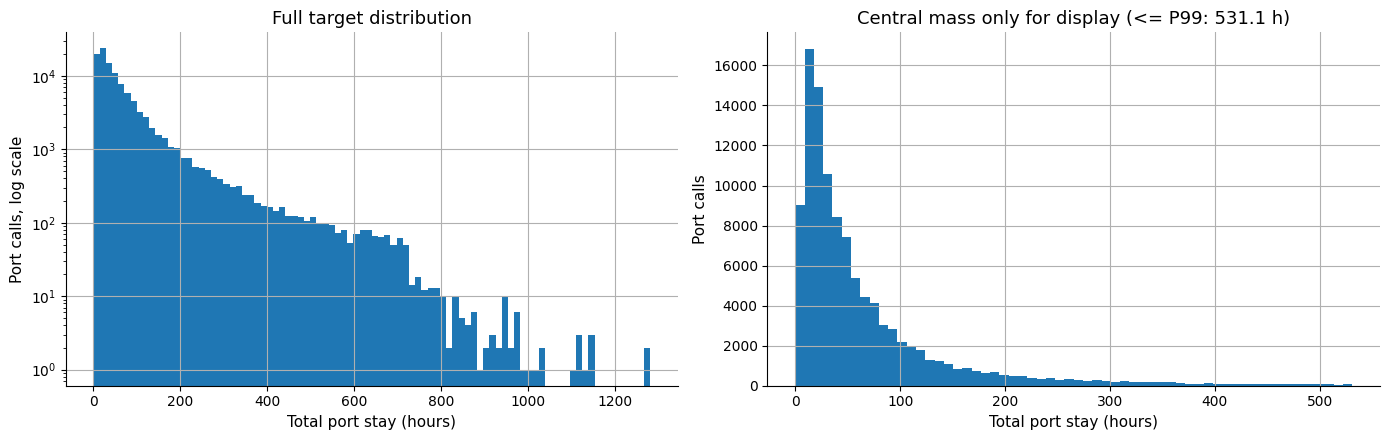

In [4]:
target_dev = development_df[TARGET]
target_summary = pd.Series(
    {
        "count": target_dev.count(),
        "mean": target_dev.mean(),
        "median": target_dev.median(),
        "std": target_dev.std(),
        "p75": target_dev.quantile(0.75),
        "p90": target_dev.quantile(0.90),
        "p95": target_dev.quantile(0.95),
        "max": target_dev.max(),
    },
    name=TARGET,
).to_frame()
display(target_summary.style.format("{:,.2f}"))

p99 = target_dev.quantile(0.99)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(target_dev, bins=90)
axes[0].set_yscale("log")
axes[0].set_title("Full target distribution")
axes[0].set_xlabel("Total port stay (hours)")
axes[0].set_ylabel("Port calls, log scale")

axes[1].hist(target_dev[target_dev <= p99], bins=60)
axes[1].set_title(f"Central mass only for display (<= P99: {p99:,.1f} h)")
axes[1].set_xlabel("Total port stay (hours)")
axes[1].set_ylabel("Port calls")

plt.tight_layout()
plt.show()

## 5. Temporal Overview

Port calls are time-dependent. Chronological evaluation is preferable to random splitting because an operational model is trained on the past and applied to future arrivals.

,arrival_port_ts,port_calls,median_stay_h,p90_stay_h
25,2025-02-01,3483,36.183333,147.276667
26,2025-03-01,3763,40.666667,177.423333
27,2025-04-01,3508,36.791667,153.833333
28,2025-05-01,3659,39.250000,153.500000
29,2025-06-01,3319,40.166667,157.133333


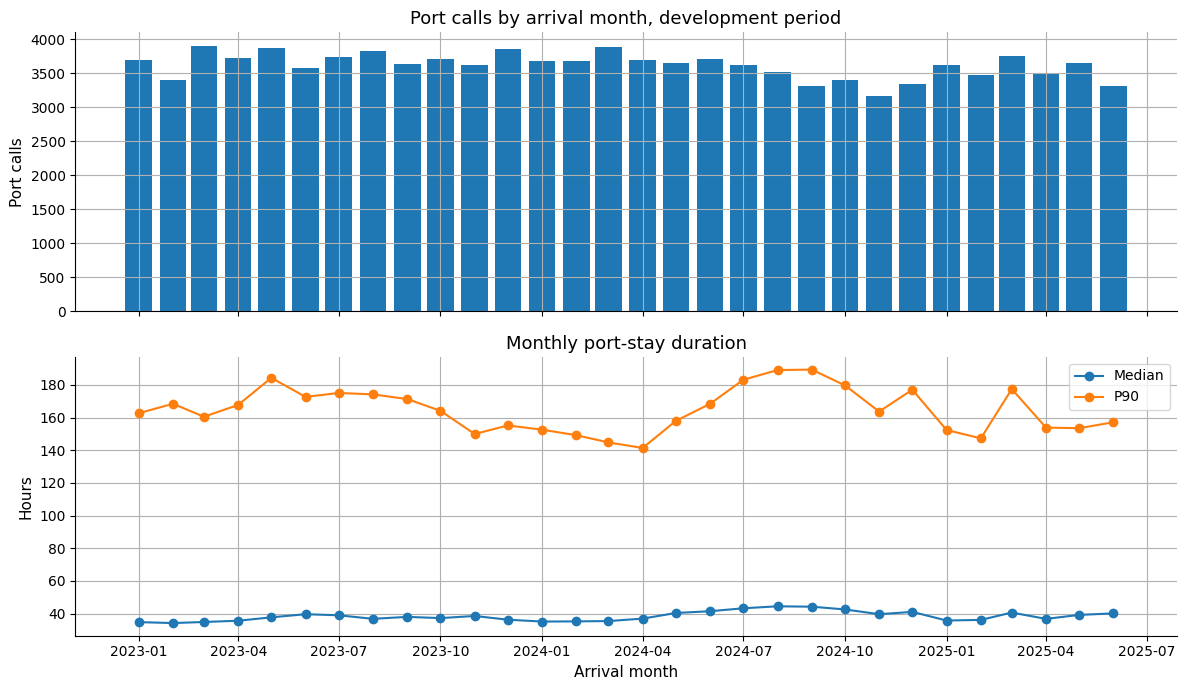

In [5]:
monthly = (
    development_df.set_index(DATE_COL)
    .resample("MS")
    .agg(
        port_calls=(TARGET, "size"),
        median_stay_h=(TARGET, "median"),
        p90_stay_h=(TARGET, lambda values: values.quantile(0.90)),
    )
    .reset_index()
)

display(monthly.tail())

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].bar(monthly[DATE_COL], monthly["port_calls"], width=24)
axes[0].set_title("Port calls by arrival month, development period")
axes[0].set_ylabel("Port calls")

axes[1].plot(monthly[DATE_COL], monthly["median_stay_h"], marker="o", label="Median")
axes[1].plot(monthly[DATE_COL], monthly["p90_stay_h"], marker="o", label="P90")
axes[1].set_title("Monthly port-stay duration")
axes[1].set_ylabel("Hours")
axes[1].set_xlabel("Arrival month")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Port-Level Descriptive Analysis

Ports differ in traffic volume and duration profile. Duration rankings use a minimum observation count to avoid overinterpreting very small groups.

,rows,median_stay_h,p90_stay_h
port,,,
BRRIO,"19,770",41.0,189.5
BRSSZ,"13,033",51.6,280.7
BRRJ022,"9,114",22.9,85.7
BRPNG,"6,227",30.1,134.2
BRRIG,"4,152",44.8,168.4
BRSUA,"3,574",45.0,205.3
BRARE,"2,839",5.1,10.2
BRMEA001,"2,787",28.8,96.7
BRSSA,"2,094",15.1,94.9


,rows,median_stay_h,p90_stay_h
port,,,
BRSFS,"1,124",95.9,398.7
BRSTM,563,93.3,318.8
BRREC,"1,022",87.5,231.9
BRVIX014,637,79.9,147.7
BRIBB,746,76.0,189.8
BRADR003,"1,263",72.0,210.3
BRIGI,"1,407",71.3,182.8
BRIQI,"1,926",60.9,148.9
BRSSZ,"13,033",51.6,280.7


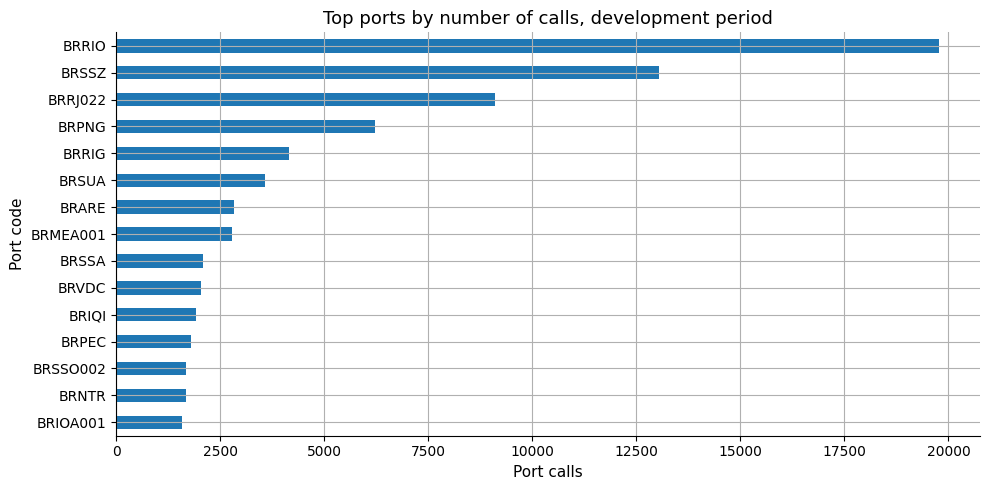

In [6]:
MIN_PORT_CALLS = 500

port_stats = (
    development_df.groupby("port", dropna=False)
    .agg(
        rows=(TARGET, "size"),
        median_stay_h=(TARGET, "median"),
        p90_stay_h=(TARGET, lambda values: values.quantile(0.90)),
    )
    .sort_values("rows", ascending=False)
)

display(port_stats.head(15).style.format({"rows": "{:,.0f}", "median_stay_h": "{:,.1f}", "p90_stay_h": "{:,.1f}"}))

duration_rank = port_stats[port_stats["rows"] >= MIN_PORT_CALLS].sort_values("median_stay_h", ascending=False).head(12)
display(duration_rank.style.format({"rows": "{:,.0f}", "median_stay_h": "{:,.1f}", "p90_stay_h": "{:,.1f}"}))

fig, ax = plt.subplots(figsize=(10, 5))
port_stats.head(15).sort_values("rows").plot(kind="barh", y="rows", ax=ax, legend=False)
ax.set_title("Top ports by number of calls, development period")
ax.set_xlabel("Port calls")
ax.set_ylabel("Port code")
plt.tight_layout()
plt.show()

## 7. Leakage Awareness

Temporal leakage happens when a model uses information that would not yet exist at the prediction timestamp. Here, a predictor is valid only if it is known at `arrival_port_ts` or reconstructed exclusively from information already available before that instant.

The model-ready CSV was built from the repository data dictionary and publication checks. It excludes post-arrival realized variables and includes historical context features built with temporal cutoffs. Full column-level source and availability documentation remains in the GitHub repository.

In [7]:
leakage_summary = pd.DataFrame(
    [
        ("feature", "Predictors included in this CSV because they are available at arrival or reconstructed from prior information."),
        ("target", "`t_total_port_stay_h`, retained for supervised training and evaluation."),
        ("identifier / metadata", "`port_call_id`, `arrival_port_ts`, and `split`, retained for reproducibility and temporal evaluation."),
        ("excluded from model-ready", "Post-arrival timestamps, realized duration components, target-derived flags, same-day realized weather, QC flags, and unsafe EDA congestion proxies."),
    ],
    columns=["role", "meaning"],
)
display(leakage_summary)

,role,meaning
0,feature,Predictors included in this CSV because they a...
1,target,"`t_total_port_stay_h`, retained for supervised..."
2,identifier / metadata,"`port_call_id`, `arrival_port_ts`, and `split`..."
3,excluded from model-ready,"Post-arrival timestamps, realized duration com..."


## 8. Official Temporal Split

The official split is chronological:

- `train`: 2023-01-01 <= arrival < 2024-07-01
- `validation`: 2024-07-01 <= arrival < 2025-01-01
- `calibration`: 2025-01-01 <= arrival < 2025-07-01
- `final_test`: 2025-07-01 <= arrival < 2026-01-01

The final test period remains untouched until the final locked evaluation.

,rows,start,end,pct
split,,,,
train,"66,909",2023-01-01 00:08:00,2024-06-30 23:30:00,51.6%
validation,"20,362",2024-07-01 00:00:00,2024-12-31 22:40:00,15.7%
calibration,"21,352",2025-01-01 00:05:00,2025-06-30 23:40:00,16.5%
final_test,"21,002",2025-07-01 00:00:00,2025-12-31 23:00:00,16.2%


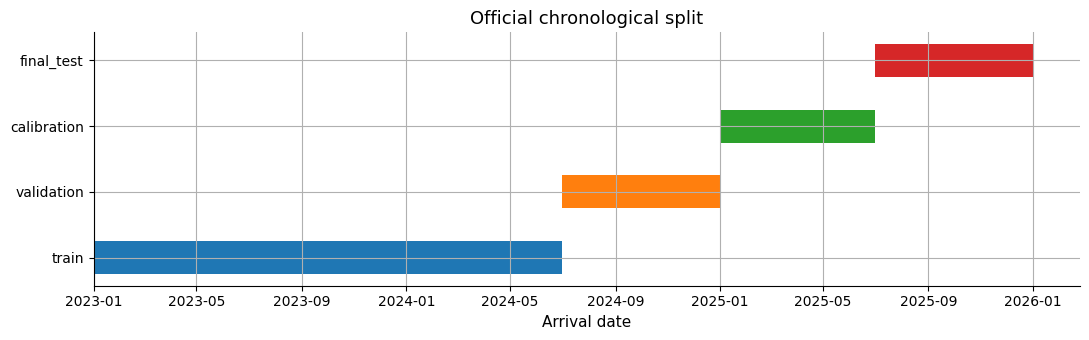

In [8]:
split_summary = (
    df.groupby(SPLIT_COL)
    .agg(
        rows=(ID_COL, "size"),
        start=(DATE_COL, "min"),
        end=(DATE_COL, "max"),
    )
    .reindex(SPLIT_ORDER)
)
split_summary["pct"] = split_summary["rows"] / len(df)
display(split_summary.style.format({"rows": "{:,.0f}", "pct": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(11, 3.5))
for y, split_name in enumerate(SPLIT_ORDER):
    start = pd.Timestamp(split_bounds[split_name][0])
    end = pd.Timestamp(split_bounds[split_name][1])
    left = mdates.date2num(start)
    width = mdates.date2num(end) - left
    ax.barh(y, width, left=left, height=0.5, label=split_name)

ax.set_yticks(range(len(SPLIT_ORDER)), SPLIT_ORDER)
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.set_title("Official chronological split")
ax.set_xlabel("Arrival date")
plt.tight_layout()
plt.show()

## 9. Naive Baseline

The first baseline predicts the global median target observed in `train`. It is simple, robust to the long tail, and useful as a sanity check.

In [9]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "Median Absolute Error": median_absolute_error(y_true, y_pred),
    }


train_df = df[df[SPLIT_COL] == "train"].copy()
validation_df = df[df[SPLIT_COL] == "validation"].copy()

train_median = train_df[TARGET].median()
validation_pred_median = np.full(len(validation_df), train_median)

validation_results = pd.DataFrame(
    [
        {
            "model": "Global Median",
            **regression_metrics(validation_df[TARGET], validation_pred_median),
        }
    ]
)
display(validation_results.style.format({"MAE": "{:,.2f}", "Median Absolute Error": "{:,.2f}"}))

,model,MAE,Median Absolute Error
0,Global Median,56.36,23.93


## 10. Machine-Learning Baseline

This baseline uses `HistGradientBoostingRegressor` with a fixed configuration. It is not tuned. The feature list is derived directly from the model-ready CSV by excluding only `port_call_id`, `arrival_port_ts`, `t_total_port_stay_h`, and `split`.

Categorical variables are ordinal-encoded here as a simple and computationally lightweight preprocessing strategy for this introductory baseline. The integer codes do not imply a meaningful natural ordering between categories. This is a baseline modeling choice, not a claim that ordinal encoding is optimal; more specialized categorical handling is left for future experiments.

In [10]:
assert len(predictors) == 120, f"Expected 120 model-ready predictors, found {len(predictors)}."

raw_X_train = train_df[predictors]
categorical_features = raw_X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_features = [column for column in predictors if column not in categorical_features]

def make_model_matrix(frame):
    X = frame[predictors].copy()
    for column in categorical_features:
        X[column] = X[column].astype("object").where(X[column].notna(), np.nan)
    return X


X_train = make_model_matrix(train_df)
X_validation = make_model_matrix(validation_df)
y_train = train_df[TARGET]
y_validation = validation_df[TARGET]

print(f"Predictors used: {len(predictors)}")
print(f"Numeric/bool predictors: {len(numeric_features)}")
print(f"Categorical predictors: {len(categorical_features)}")
display(pd.DataFrame({"feature": predictors}))

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", SimpleImputer(strategy="median"), numeric_features),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
                    (
                        "encoder",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                            encoded_missing_value=-2,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ],
    sparse_threshold=0.0,
)

hgb_params = {
    "loss": "squared_error",
    "learning_rate": 0.08,
    "max_iter": 180,
    "max_leaf_nodes": 31,
    "min_samples_leaf": 40,
    "l2_regularization": 0.10,
    "early_stopping": True,
    "validation_fraction": 0.10,
    "n_iter_no_change": 10,
    "random_state": RANDOM_STATE,
}

locked_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingRegressor(**hgb_params)),
    ]
)

fit_start = time.perf_counter()
validation_model = clone(locked_model)
validation_model.fit(X_train, y_train)
validation_pred_hgb = np.clip(validation_model.predict(X_validation), 0, None)
validation_fit_seconds = time.perf_counter() - fit_start

print(f"Validation model fit time: {validation_fit_seconds:.1f} seconds")
print("Locked HistGradientBoostingRegressor parameters:")
display(pd.Series(hgb_params, name="value").to_frame())

Predictors used: 120
Numeric/bool predictors: 115
Categorical predictors: 5


,feature
0,port
1,region
2,state
3,arrival_shift
4,arrival_season
...,...
115,opmix_carga_share_prev_7d
116,opmix_descarga_share_prev_7d
117,opmix_fundeio_share_prev_7d
118,opmix_offshore_share_prev_7d


C:\Users\tiago\miniconda3\envs\port-leadtime\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\tiago\miniconda3\envs\port-leadtime\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\tiago\miniconda3\envs\port-leadtime\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\tiago\miniconda3\envs\port-leadtime\Lib\subprocess.py", line 548, in run
    with Popen(*popenarg

Validation model fit time: 4.6 seconds
Locked HistGradientBoostingRegressor parameters:


,value
loss,squared_error
learning_rate,0.08
max_iter,180
max_leaf_nodes,31
min_samples_leaf,40
l2_regularization,0.1
early_stopping,True
validation_fraction,0.1
n_iter_no_change,10
random_state,42


## 11. Validation Comparison

Validation is used to compare the naive baseline with the fixed machine-learning baseline. We do not use the final test set here.

,model,MAE,Median Absolute Error
0,Global Median,56.36,23.93
1,HistGradientBoosting baseline,49.37,27.71


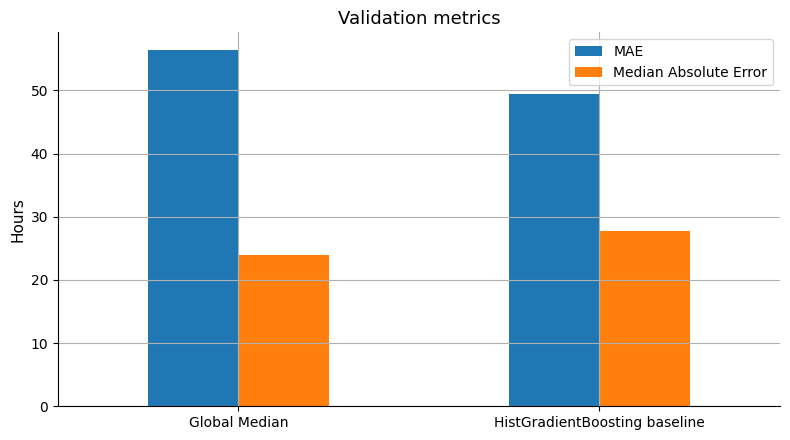

In [11]:
hgb_validation_row = {
    "model": "HistGradientBoosting baseline",
    **regression_metrics(y_validation, validation_pred_hgb),
}
validation_results = pd.concat([validation_results, pd.DataFrame([hgb_validation_row])], ignore_index=True)
display(validation_results.style.format({"MAE": "{:,.2f}", "Median Absolute Error": "{:,.2f}"}))

fig, ax = plt.subplots(figsize=(8, 4.5))
validation_results.set_index("model")[["MAE", "Median Absolute Error"]].plot(kind="bar", ax=ax)
ax.set_title("Validation metrics")
ax.set_ylabel("Hours")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### Validation Interpretation

On validation, the global median baseline has MAE = 56.36 h and Median Absolute Error = 23.93 h. The fixed HistGradientBoosting baseline has MAE = 49.37 h and Median Absolute Error = 27.71 h.

That means the HGB baseline reduces validation MAE by approximately 12.4%, but its Median Absolute Error is higher. The model is therefore not uniformly better under every metric. This fixed HGB configuration uses squared-error loss and is not optimized for median absolute error. In a long-tailed target, reducing some larger errors can improve MAE without improving the typical absolute error.

## 12. Locked Final Evaluation

Now that preprocessing, features, and model parameters are fixed, we combine `train`, `validation`, and `calibration`, fit the same pipeline once, and evaluate on `final_test`.

The final-test results are reported once and should not be used to revise the model inside this notebook.

,model,evaluation_period,MAE,Median Absolute Error
0,HistGradientBoosting baseline,final_test,43.50,25.03


Final locked model fit time: 6.6 seconds


,actual_stay_bin,rows,mae_h,medae_h
0,<= 1 day,"6,430",28.10,18.86
1,1-3 days,"8,581",29.65,20.93
2,3-7 days,"4,066",37.86,29.61
3,7-14 days,"1,363",107.22,102.60
4,> 14 days,562,317.48,297.49


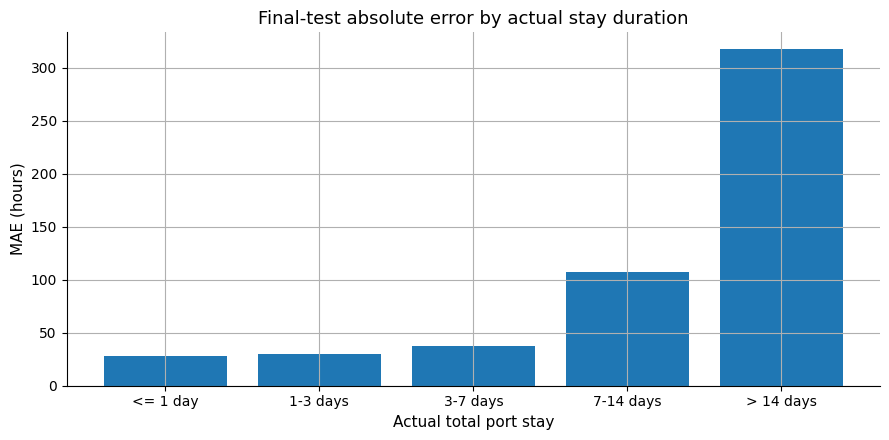

In [12]:
development_for_final = df[df[SPLIT_COL].isin(DEVELOPMENT_SPLITS)].copy()
final_holdout_df = df[df[SPLIT_COL] == "final_test"].copy()

final_model = clone(locked_model)
final_fit_start = time.perf_counter()
final_model.fit(make_model_matrix(development_for_final), development_for_final[TARGET])
final_predictions = np.clip(final_model.predict(make_model_matrix(final_holdout_df)), 0, None)
final_fit_seconds = time.perf_counter() - final_fit_start

final_results = pd.DataFrame(
    [
        {
            "model": "HistGradientBoosting baseline",
            "evaluation_period": "final_test",
            **regression_metrics(final_holdout_df[TARGET], final_predictions),
        }
    ]
)
display(final_results.style.format({"MAE": "{:,.2f}", "Median Absolute Error": "{:,.2f}"}))
print(f"Final locked model fit time: {final_fit_seconds:.1f} seconds")

errors = final_holdout_df[[TARGET]].copy()
errors["absolute_error_h"] = np.abs(final_holdout_df[TARGET].to_numpy() - final_predictions)
duration_bins = [0, 24, 72, 168, 336, np.inf]
duration_labels = ["<= 1 day", "1-3 days", "3-7 days", "7-14 days", "> 14 days"]
errors["actual_stay_bin"] = pd.cut(
    errors[TARGET],
    bins=duration_bins,
    labels=duration_labels,
    include_lowest=True,
    right=True,
)
error_by_bin = (
    errors.groupby("actual_stay_bin", observed=False)
    .agg(rows=(TARGET, "size"), mae_h=("absolute_error_h", "mean"), medae_h=("absolute_error_h", "median"))
    .reset_index()
)
display(error_by_bin.style.format({"rows": "{:,.0f}", "mae_h": "{:,.2f}", "medae_h": "{:,.2f}"}))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(error_by_bin["actual_stay_bin"].astype(str), error_by_bin["mae_h"])
ax.set_title("Final-test absolute error by actual stay duration")
ax.set_xlabel("Actual total port stay")
ax.set_ylabel("MAE (hours)")
plt.tight_layout()
plt.show()

### Public Baseline Result

The final public-baseline result reported here is MAE = 43.50 h and Median Absolute Error = 25.03 h on `final_test`.

These numbers should not be interpreted as a reproduction of the final thesis model. This notebook intentionally uses one fixed, untuned baseline model, simplified preprocessing, and the sanitized public Kaggle dataset. The full academic workflow used a broader experimental process and is documented in the GitHub repository. Direct metric equality with thesis results is not expected.

## 13. Conclusions

Key lessons from this first pass:

- Port stay duration is strongly right-skewed, with a long tail of difficult calls.
- Chronological splitting is a better fit than random splitting because prediction happens forward in time.
- Leakage prevention matters: post-arrival timestamps, realized durations, target-derived flags, and same-day realized weather should not be used as arrival-time predictors.
- Historical context can be useful when reconstructed with proper temporal cutoffs.
- Long-duration calls remain harder to predict, even for a tree-based baseline.

This notebook is a starting point. It does not reproduce the full thesis experiment. For the complete academic workflow, including richer modeling, quantile regression, uncertainty analysis, and safety-stock simulation, see:

https://github.com/tiagoalberione/port-leadtime-prediction

In [13]:
elapsed = time.perf_counter() - NOTEBOOK_START
print(f"Notebook runtime measured inside Python: {elapsed:.1f} seconds")

Notebook runtime measured inside Python: 14.5 seconds
